# WISDM 2단 활동 분류 최종 정리 노트북

이 노트북은 **최종 성능 평가용**으로 정리한 버전입니다.

- 불필요한 중간 실험 코드는 제거
- 필요한 실험 템플릿은 마지막에 **주석 처리**
- 최종 출력:
  - Final 3-Class **Accuracy / F1(Macro, Weighted)**
  - Final 3-Class **Confusion Matrix**
  - Stage1 / Stage2 **Permutation Importance**
  - 최종 최적 모델 **PKL 저장**


In [1]:

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ------------------------------------------------------------
# 설정
# ------------------------------------------------------------
DATA_PATH = Path("../data/processed/sensor_ADE.csv")
SAVE_DIR = Path("../models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_SIZE = 50
STEP_SIZE = 25
SKIP_HEAD = 80
NOISE_STD_MULTIPLIER = 1.5

TARGET_ACTIVITIES = ["Standing", "Sitting", "Walking"]
FEATURE_COLUMNS = ["x", "y", "z", "magnitude"]

ACTIVITY_MAP = {
    "A": "Walking",
    "D": "Sitting",
    "E": "Standing",
}

RANDOM_STATE = 42


In [ ]:
'''
data_dir = Path("../data/raw")
txt_files = list(data_dir.glob("*.txt"))
output_path = Path("../data/processed/")
output_path.mkdir(parents=True, exist_ok=True)

# 제출/재실행 시 바로 원인을 알 수 있도록 입력 파일 존재 여부를 먼저 확인
if not txt_files:
    raise FileNotFoundError(f"입력 파일을 찾을 수 없습니다: {data_dir.resolve()}")

# 파일 이름에서 subject_id, sensor, device 추출
def parse_filename(file_path):
    name = file_path.stem  # 예: data_1600_accel_watch

    parts = name.split("_")

    subject_id = parts[1]      # 1600
    sensor = parts[2]          # accel or gyro
    device = parts[3]          # watch

    return subject_id, sensor, device

# 각 txt 파일을 읽어서 센서 데이터프레임으로 변환
def load_sensor_file(file_path):
    subject_id_from_name, sensor, device = parse_filename(file_path)

    raw_df = pd.read_csv(
        file_path,
        sep=",",
        header=None,
        engine="python"
    )

    raw_df.columns = ["subject_id", "activity", "timestamp", "x", "y", "z"]

    # 원본 데이터의 z축 끝 세미콜론 제거
    raw_df["z"] = raw_df["z"].astype(str).str.replace(";", "", regex=False)

    # 모델 학습 전 숫자형/문자형 타입 정리
    raw_df["subject_id"] = raw_df["subject_id"].astype(str)
    raw_df["activity"] = raw_df["activity"].astype(str)
    raw_df["timestamp"] = pd.to_numeric(raw_df["timestamp"], errors="coerce")
    raw_df["x"] = pd.to_numeric(raw_df["x"], errors="coerce")
    raw_df["y"] = pd.to_numeric(raw_df["y"], errors="coerce")
    raw_df["z"] = pd.to_numeric(raw_df["z"], errors="coerce")

    # 파일명에서 분리한 메타정보 추가
    raw_df["sensor"] = sensor
    raw_df["device"] = device

    return raw_df

# 모든 파일을 읽어서 하나의 데이터프레임으로 결합
all_dfs = []
for file_path in txt_files:
    df = load_sensor_file(file_path)
    all_dfs.append(df)

full_df = pd.concat(all_dfs, ignore_index=True)

# 본 과제에서는 A, D, E 활동만 사용
selected_activities = ["A", "D", "E"]
filtered_df = full_df[full_df["activity"].isin(selected_activities)].copy()

# 활동 코드에 대한 이름 매핑
activity_map = {
    "A": "Walking",
    "D": "Sitting",
    "E": "Standing"
}
filtered_df["activity_name"] = filtered_df["activity"].map(activity_map)

# 필요한 열만 선택하여 최종 데이터프레임 생성
filtered_df = filtered_df[
    ["subject_id", "activity", "activity_name", "timestamp", "sensor", "device", "x", "y", "z"]
]

# 전처리 중간 결과 저장
filtered_df.to_csv(output_path / "sensor_ADE.csv", index=False)
'''

In [2]:

# ------------------------------------------------------------
# 데이터 로드 / 기본 전처리
# ------------------------------------------------------------
df = pd.read_csv(DATA_PATH)

if "activity_name" not in df.columns and "act" in df.columns:
    df["activity_name"] = df["act"].map(ACTIVITY_MAP)

df = df[
    (df["subject_id"].between(1600, 1650)) &
    (df["device"] == "watch") &
    (df["activity_name"].isin(TARGET_ACTIVITIES))
].copy()

df = df.sort_values(["subject_id", "activity_name", "sensor", "timestamp"]).copy()
df["magnitude"] = np.sqrt(df["x"] ** 2 + df["y"] ** 2 + df["z"] ** 2)

print("filtered df shape:", df.shape)
display(df.head())


# ------------------------------------------------------------
# 윈도우 feature 추출
# ------------------------------------------------------------
def extract_window_features(window_df, prefix):
    features = {}

    for col in FEATURE_COLUMNS:
        values = window_df[col].to_numpy()

        features[f"{prefix}_{col}_mean"] = values.mean()
        features[f"{prefix}_{col}_std"] = values.std()
        features[f"{prefix}_{col}_min"] = values.min()
        features[f"{prefix}_{col}_max"] = values.max()
        features[f"{prefix}_{col}_range"] = values.max() - values.min()
        features[f"{prefix}_{col}_median"] = np.median(values)
        features[f"{prefix}_{col}_energy"] = np.mean(values ** 2)

    return features


def build_sensor_feature_df(
    source_df,
    sensor_name,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    skip_head=SKIP_HEAD,
    apply_noise_filter=True,
    noise_std_multiplier=NOISE_STD_MULTIPLIER,
):
    rows = []

    sensor_df = source_df[source_df["sensor"] == sensor_name].copy()

    for (subject_id, activity_name), group in sensor_df.groupby(["subject_id", "activity_name"]):
        group = group.sort_values("timestamp").reset_index(drop=True)

        if skip_head > 0:
            group = group.iloc[skip_head:].reset_index(drop=True)

        n = len(group)
        group_rows = []
        window_seq = 0

        for start in range(0, n - window_size + 1, step_size):
            window_df = group.iloc[start:start + window_size].copy()

            magnitude = np.sqrt(
                window_df["x"].to_numpy() ** 2 +
                window_df["y"].to_numpy() ** 2 +
                window_df["z"].to_numpy() ** 2
            )
            noise_score = float(np.std(magnitude, ddof=0))

            feat = extract_window_features(window_df, prefix=sensor_name)
            feat["subject_id"] = subject_id
            feat["activity_name"] = activity_name
            feat["window_seq"] = window_seq
            feat["noise_score"] = noise_score

            group_rows.append(feat)
            window_seq += 1

        if len(group_rows) == 0:
            continue

        group_feat_df = pd.DataFrame(group_rows)

        if apply_noise_filter:
            score_mean = group_feat_df["noise_score"].mean()
            score_std = group_feat_df["noise_score"].std(ddof=0)
            threshold = score_mean + noise_std_multiplier * score_std
            group_feat_df = group_feat_df[group_feat_df["noise_score"] <= threshold].copy()

        rows.append(group_feat_df)

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


accel_feat_df = build_sensor_feature_df(df, sensor_name="accel")
gyro_feat_df = build_sensor_feature_df(df, sensor_name="gyro")

fusion_df = accel_feat_df.merge(
    gyro_feat_df,
    on=["subject_id", "activity_name", "window_seq"],
    how="inner"
)

print("accel_feat_df:", accel_feat_df.shape)
print("gyro_feat_df :", gyro_feat_df.shape)
print("fusion_df    :", fusion_df.shape)
display(fusion_df.head())

# 필요 시 feature 저장
# accel_feat_df.to_csv("../data/processed/accel_feat_df.csv", index=False)
# gyro_feat_df.to_csv("../data/processed/gyro_feat_df.csv", index=False)
# fusion_df.to_csv("../data/processed/fusion_df.csv", index=False)


filtered df shape: (1221726, 10)


,subject_id,activity,activity_name,timestamp,sensor,device,x,y,z,magnitude
3605,1600,D,Sitting,79817308824838,accel,watch,-0.166696,1.531691,10.057592,10.174921
3606,1600,D,Sitting,79817358500488,accel,watch,3.613748,-1.054047,11.779023,12.365904
3607,1600,D,Sitting,79817408176138,accel,watch,2.088642,-3.438672,12.973730,13.583246
3608,1600,D,Sitting,79817457851788,accel,watch,1.731906,-2.550423,9.820566,10.293089
3609,1600,D,Sitting,79817507527438,accel,watch,3.031957,-2.780267,14.082246,14.670798


accel_feat_df: (23172, 32)
gyro_feat_df : (20802, 32)
fusion_df    : (20080, 61)


,accel_x_mean,accel_x_std,accel_x_min,accel_x_max,accel_x_range,accel_x_median,accel_x_energy,accel_y_mean,accel_y_std,accel_y_min,...,gyro_z_median,gyro_z_energy,gyro_magnitude_mean,gyro_magnitude_std,gyro_magnitude_min,gyro_magnitude_max,gyro_magnitude_range,gyro_magnitude_median,gyro_magnitude_energy,noise_score_y
0,2.920340,0.051922,2.780566,3.031957,0.251391,2.925415,8.531079,-1.676588,0.065341,-1.793856,...,0.012214,0.001377,0.039299,0.022105,0.009404,0.088576,0.079172,0.034660,0.002033,0.022105
1,2.930874,0.043607,2.804508,3.010409,0.205901,2.937386,8.591924,-1.649485,0.059794,-1.769914,...,0.002092,0.000142,0.022601,0.012250,0.006763,0.072876,0.066112,0.019797,0.000661,0.012250
2,2.924458,0.053427,2.804508,3.067870,0.263362,2.926612,8.555307,-1.644936,0.084254,-1.791462,...,0.003155,0.000057,0.027384,0.018239,0.005245,0.086350,0.081104,0.022311,0.001083,0.018239
3,2.929916,0.048434,2.823662,3.067870,0.244209,2.932598,8.586756,-1.643596,0.084788,-1.791462,...,0.000492,0.000025,0.025191,0.017501,0.005245,0.086350,0.081104,0.020368,0.000941,0.017501
4,2.928145,0.045535,2.780566,3.017592,0.237026,2.932598,8.576105,-1.674912,0.080940,-1.872864,...,0.002087,0.000040,0.024533,0.018809,0.005656,0.089336,0.083679,0.017938,0.000956,0.018809


X_full_train: (16008, 58)
X_full_test : (4072, 58)
X2_train_full: (10841, 58)
X2_test_full : (2699, 58)
=== Final 3-Class Evaluation ===


,accuracy,f1_macro,f1_weighted,window_size,step_size,skip_head
0,0.880403,0.879716,0.880552,50,25,80


              precision    recall  f1-score   support

     Walking     1.0000    0.9985    0.9993      1373
     Sitting     0.8655    0.7846    0.8231      1444
    Standing     0.7766    0.8614    0.8168      1255

    accuracy                         0.8804      4072
   macro avg     0.8807    0.8815    0.8797      4072
weighted avg     0.8835    0.8804    0.8806      4072

Confusion Matrix:
[[1371    2    0]
 [   0 1133  311]
 [   0  174 1081]]


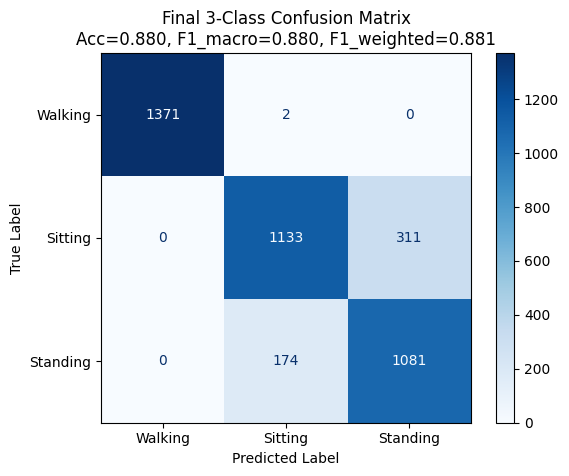

In [3]:

# ------------------------------------------------------------
# 2단 분류 helper
# ------------------------------------------------------------
def predict_3class_with_two_stage(stage1_model, stage2_model, X):
    '''
    stage1:
        1 -> Walking
        0 -> Static
    stage2:
        0 -> Sitting
        1 -> Standing
    final:
        Walking=0, Sitting=1, Standing=2
    '''
    stage1_pred = stage1_model.predict(X)
    final_pred = []

    for i in range(len(X)):
        if stage1_pred[i] == 1:
            final_pred.append(0)
        else:
            stage2_pred = stage2_model.predict(X.iloc[[i]])[0]
            final_pred.append(1 if stage2_pred == 0 else 2)

    return np.array(final_pred)


def make_group_split_with_meta(X, y, groups, meta_df, test_size=0.2, random_state=RANDOM_STATE):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(X, y, groups))

    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)

    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    meta_train = meta_df.iloc[train_idx].reset_index(drop=True)
    meta_test = meta_df.iloc[test_idx].reset_index(drop=True)

    return X_train, X_test, y_train, y_test, meta_train, meta_test


# ------------------------------------------------------------
# 최종 학습 데이터 구성
# ------------------------------------------------------------
label_map_3class = {
    "Walking": 0,
    "Sitting": 1,
    "Standing": 2
}

full_df = fusion_df.copy()
full_df["target_3class"] = full_df["activity_name"].map(label_map_3class)

meta_cols = ["subject_id", "activity_name", "window_seq", "target_3class"]
X_full = full_df.drop(columns=meta_cols)
y_full = full_df["target_3class"]
groups_full = full_df["subject_id"]

X_full_train, X_full_test, y_full_train, y_full_test, train_meta, test_meta = make_group_split_with_meta(
    X=X_full,
    y=y_full,
    groups=groups_full,
    meta_df=full_df,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Stage1: Walking vs Static
y1_train_full = (train_meta["activity_name"] == "Walking").astype(int)
y1_test_full = (test_meta["activity_name"] == "Walking").astype(int)

# Stage2: Sitting vs Standing
static_train_mask = train_meta["activity_name"].isin(["Sitting", "Standing"])
static_test_mask = test_meta["activity_name"].isin(["Sitting", "Standing"])

X2_train_full = X_full_train[static_train_mask].reset_index(drop=True)
y2_train_full = train_meta.loc[static_train_mask, "activity_name"].map({
    "Sitting": 0,
    "Standing": 1
}).reset_index(drop=True)

X2_test_full = X_full_test[static_test_mask].reset_index(drop=True)
y2_test_full = test_meta.loc[static_test_mask, "activity_name"].map({
    "Sitting": 0,
    "Standing": 1
}).reset_index(drop=True)

print("X_full_train:", X_full_train.shape)
print("X_full_test :", X_full_test.shape)
print("X2_train_full:", X2_train_full.shape)
print("X2_test_full :", X2_test_full.shape)


# ------------------------------------------------------------
# 최종 베스트 모델
# ------------------------------------------------------------
stage1_model_full = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=3.0, gamma="scale", probability=True, random_state=RANDOM_STATE))
])

stage2_model_full = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=3.0, gamma="scale", probability=True, random_state=RANDOM_STATE))
])

stage1_model_full.fit(X_full_train, y1_train_full)
stage2_model_full.fit(X2_train_full, y2_train_full)


# ------------------------------------------------------------
# 최종 평가
# ------------------------------------------------------------
y_full_pred = predict_3class_with_two_stage(
    stage1_model=stage1_model_full,
    stage2_model=stage2_model_full,
    X=X_full_test
)

target_names_3class = ["Walking", "Sitting", "Standing"]

final_accuracy = accuracy_score(y_full_test, y_full_pred)
final_f1_macro = f1_score(y_full_test, y_full_pred, average="macro")
final_f1_weighted = f1_score(y_full_test, y_full_pred, average="weighted")

metrics_df = pd.DataFrame([{
    "accuracy": final_accuracy,
    "f1_macro": final_f1_macro,
    "f1_weighted": final_f1_weighted,
    "window_size": WINDOW_SIZE,
    "step_size": STEP_SIZE,
    "skip_head": SKIP_HEAD,
}])

print("=== Final 3-Class Evaluation ===")
display(metrics_df)

print(classification_report(
    y_full_test,
    y_full_pred,
    target_names=target_names_3class,
    digits=4
))

cm = confusion_matrix(y_full_test, y_full_pred)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names_3class
)
disp.plot(values_format="d", cmap="Blues")
plt.title(
    f"Final 3-Class Confusion Matrix\n"
    f"Acc={final_accuracy:.3f}, F1_macro={final_f1_macro:.3f}, F1_weighted={final_f1_weighted:.3f}"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


=== Stage1 Permutation Importance (SVM) ===


,feature,importance
22,accel_magnitude_std,0.061076
28,noise_score_x,0.061076
23,accel_magnitude_min,0.001940
29,gyro_x_mean,0.000491
31,gyro_x_min,0.000491
8,accel_y_std,0.000442
38,gyro_y_min,0.000344
4,accel_x_range,0.000344
7,accel_y_mean,0.000270
1,accel_x_std,0.000270


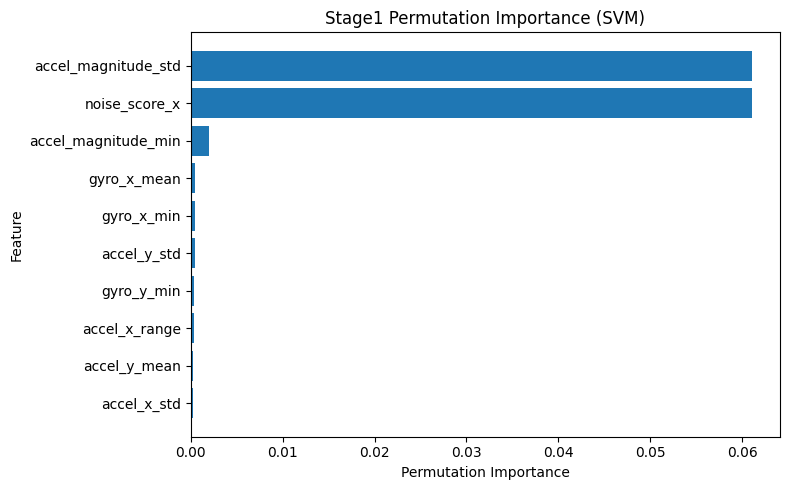

=== Stage2 Permutation Importance (SVM) ===


,feature,importance
6,accel_x_energy,0.041015
13,accel_y_energy,0.021489
21,accel_magnitude_mean,0.013672
27,accel_magnitude_energy,0.012264
26,accel_magnitude_median,0.009003
16,accel_z_min,0.007632
17,accel_z_max,0.007077
19,accel_z_median,0.006928
14,accel_z_mean,0.006410
37,gyro_y_std,0.005817


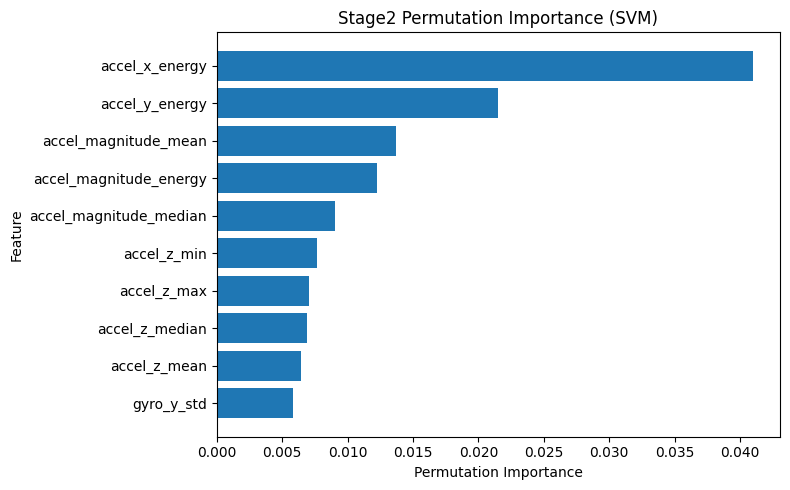

In [4]:

# ------------------------------------------------------------
# Permutation Importance
# ------------------------------------------------------------
def get_feature_names(X):
    if hasattr(X, "columns"):
        return list(X.columns)
    return [f"feature_{i}" for i in range(X.shape[1])]


def plot_permutation_importance(
    model,
    X_eval,
    y_eval,
    title,
    top_n=10,
    scoring="accuracy",
    n_repeats=10,
    random_state=RANDOM_STATE
):
    feature_names = get_feature_names(X_eval)

    result = permutation_importance(
        estimator=model,
        X=X_eval,
        y=y_eval,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": result.importances_mean
    }).sort_values("importance", ascending=False)

    print(f"=== {title} ===")
    display(importance_df.head(top_n))

    top_df = importance_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(8, 5))
    plt.barh(top_df["feature"], top_df["importance"])
    plt.title(title)
    plt.xlabel("Permutation Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    return importance_df


stage1_importance_df = plot_permutation_importance(
    model=stage1_model_full,
    X_eval=X_full_test,
    y_eval=y1_test_full,
    title="Stage1 Permutation Importance (SVM)",
    top_n=10
)

stage2_importance_df = plot_permutation_importance(
    model=stage2_model_full,
    X_eval=X2_test_full,
    y_eval=y2_test_full,
    title="Stage2 Permutation Importance (SVM)",
    top_n=10
)


In [5]:

# ------------------------------------------------------------
# 최종 베스트 모델 / 메타데이터 저장
# ------------------------------------------------------------
best_bundle = {
    "stage1_model": stage1_model_full,
    "stage2_model": stage2_model_full,
    "feature_columns": list(X_full.columns),
    "label_map_3class": label_map_3class,
    "stage1_label_desc": {"0": "Static", "1": "Walking"},
    "stage2_label_desc": {"0": "Sitting", "1": "Standing"},
    "config": {
        "window_size": WINDOW_SIZE,
        "step_size": STEP_SIZE,
        "skip_head": SKIP_HEAD,
        "noise_std_multiplier": NOISE_STD_MULTIPLIER,
        "random_state": RANDOM_STATE,
    },
    "metrics": {
        "accuracy": float(final_accuracy),
        "f1_macro": float(final_f1_macro),
        "f1_weighted": float(final_f1_weighted),
    }
}

best_bundle_path = SAVE_DIR / "two_stage_activity_classifier_best.pkl"
stage1_path = SAVE_DIR / "stage1_walking_vs_static_best.pkl"
stage2_path = SAVE_DIR / "stage2_sitting_vs_standing_best.pkl"
metrics_csv_path = SAVE_DIR / "two_stage_activity_classifier_best_metrics.csv"
metrics_json_path = SAVE_DIR / "two_stage_activity_classifier_best_metrics.json"

joblib.dump(best_bundle, best_bundle_path)
joblib.dump(stage1_model_full, stage1_path)
joblib.dump(stage2_model_full, stage2_path)

metrics_df.to_csv(metrics_csv_path, index=False, encoding="utf-8-sig")
metrics_json_path.write_text(
    json.dumps(best_bundle["metrics"], ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print("모델 저장 완료")
print("-", best_bundle_path)
print("-", stage1_path)
print("-", stage2_path)
print("지표 저장 완료")
print("-", metrics_csv_path)
print("-", metrics_json_path)


모델 저장 완료
- ..\models\two_stage_activity_classifier_best.pkl
- ..\models\stage1_walking_vs_static_best.pkl
- ..\models\stage2_sitting_vs_standing_best.pkl
지표 저장 완료
- ..\models\two_stage_activity_classifier_best_metrics.csv
- ..\models\two_stage_activity_classifier_best_metrics.json


In [6]:

# ------------------------------------------------------------
# [선택] 추가 실험 템플릿
# 필요할 때만 아래 주석을 해제해서 사용
# ------------------------------------------------------------

'''
# 1) window size 비교 실험 예시
for window_size in [50, 100, 150, 200]:
    # WINDOW_SIZE만 바꿔서 fusion_df 재생성 후
    # 동일한 평가 루틴을 다시 실행
    pass

# 2) Stage2 모델 비교 실험 예시
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

candidate_models = {
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=3.0, gamma="scale", probability=True, random_state=RANDOM_STATE))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
}

# 3) 결과 저장 예시
# results_df = pd.DataFrame([...])
# results_df.to_csv("../results/experiment_results.csv", index=False, encoding="utf-8-sig")
'''


'\n# 1) window size 비교 실험 예시\nfor window_size in [50, 100, 150, 200]:\n    # WINDOW_SIZE만 바꿔서 fusion_df 재생성 후\n    # 동일한 평가 루틴을 다시 실행\n    pass\n\n# 2) Stage2 모델 비교 실험 예시\nfrom sklearn.neighbors import KNeighborsClassifier\nfrom sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier\nfrom sklearn.linear_model import LogisticRegression\n\ncandidate_models = {\n    "SVM": Pipeline([\n        ("scaler", StandardScaler()),\n        ("clf", SVC(kernel="rbf", C=3.0, gamma="scale", probability=True, random_state=RANDOM_STATE))\n    ]),\n    "KNN": Pipeline([\n        ("scaler", StandardScaler()),\n        ("clf", KNeighborsClassifier(n_neighbors=5))\n    ]),\n    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),\n    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),\n    "LogisticRegression": Pipeline([\n        ("scaler", StandardScaler()),\n        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))\n    ]),\n}\